In [1]:
import pandas as pd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


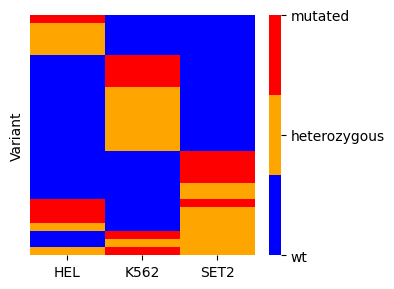

In [2]:
col_order = ['HEL','K562','SET2']
mutations = pd.read_csv('../data/3cl_predicted_genotypes.csv',index_col=0)
mutations['genotype_from_bulk'] = mutations['genotype_from_bulk'].map({'homozygous_ref': 0, 'heterozygous': 1, 'homozygous_alt': 2})

mutations_pivot = mutations.pivot(index='name', columns='cell_type', values='genotype_from_bulk').dropna()
mutations_pivot = mutations_pivot[col_order]
mutations_pivot = mutations_pivot.drop('HTT c.8157G>A') ### drop because we are not confident in genotyping

group1 = mutations_pivot.loc[mutations_pivot[col_order[0]] != 0].sort_values(col_order, ascending=[False, True, True]).index
group2 = mutations_pivot.loc[(mutations_pivot[col_order[0]] == 0) & (mutations_pivot[col_order[1]] != 0)].sort_values(col_order[1:], ascending=[False, True]).index
group3 = mutations_pivot.loc[(mutations_pivot[col_order[0]] == 0) & (mutations_pivot[col_order[1]] == 0)].sort_values(col_order[2:], ascending=[False]).index

group1 = mutations_pivot.loc[(mutations_pivot != 0).sum(axis=1) == 1].sort_values(col_order, ascending=[False, False, False]).index
group2 = mutations_pivot.loc[(mutations_pivot != 0).sum(axis=1) == 2].sort_values(col_order, ascending=[False, False, False]).index
group3 = mutations_pivot.loc[(mutations_pivot != 0).sum(axis=1) == 3].sort_values(col_order, ascending=[False, False, False]).index
mutations_pivot = mutations_pivot.reindex(pd.Index(group1).append([group2, group3]))

# Create color mapping
color_map = {'homozygous_alt': 'red', 'homozygous_ref': 'blue', 'heterozygous': 'orange'}

# Create custom colormap
colors = ['blue', 'orange', 'red']
cmap = ListedColormap(colors)

# Create heatmap
plt.figure(figsize=(4,3))
sns.heatmap(mutations_pivot, cmap=cmap, cbar_kws={'ticks': [0, 1, 2]})

# Customize colorbar labels
cbar = plt.gca().collections[0].colorbar
cbar.set_ticklabels(['wt', 'heterozygous', 'mutated'])
plt.yticks([])
plt.xlabel('')
plt.ylabel('Variant')
plt.tight_layout()

plt.savefig('../plots/bulk_genotype_heatmap.pdf', bbox_inches='tight')

In [3]:
## check number of variants
len(mutations_pivot)

30